# Q3 Part 1 – Elliptic Solver for K = 5

Develop a code assuming the PDE is elliptic, using central differences for the $x, y$ derivatives.
For $\mathcal{K} = 5$ obtain a numerically converged solution using the Gauss-Seidel iterative method.

In [170]:
import numpy as np
import matplotlib.pyplot as plt
from q3_solver import (
    solve, compute_phi_x, compute_phi_y, compute_psi,
    surface_phi_x, GAMMA
)

# Parameters
K = 5.0
Nx, Ny = 161, 81
q, s, r = 4.0, 4.0, 4.0
TOL = 1e-6

1. Solve for K = 5 (fully elliptic, central differences)

In [ ]:
print(f"Solving K={K}, grid {Nx}x{Ny}, domain [-{q},{s}]x[0,{r}]")
phi, info = solve(K, Nx=Nx, Ny=Ny, q=q, s=s, r=r,
                  tol=TOL, max_iter=60000, check_every=200,
                  elliptic_only=True, verbose=True)

x = info["x"]
y = info["y"]
dx, dy = info["dx"], info["dy"]

print(f"\nResult: converged={info['converged']}, iters={info['iters']}, time={info['seconds']:.2f}s")

Solving K=5.0, grid 161x81, domain [-4.0,4.0]x[0,4.0]
  it      1  |res|=2.338e+01  |upd|=1.150e-02  t=0.0s
  it   2000  |res|=9.598e-02  |upd|=3.931e-05  t=14.6s
  it   4000  |res|=3.729e-02  |upd|=1.533e-05  t=29.3s
  it   6000  |res|=1.642e-02  |upd|=6.765e-06  t=43.9s
  it   8000  |res|=7.729e-03  |upd|=3.189e-06  t=58.5s
  it  10000  |res|=3.798e-03  |upd|=1.569e-06  t=73.2s
  it  12000  |res|=1.922e-03  |upd|=7.950e-07  t=87.6s
  it  14000  |res|=9.929e-04  |upd|=4.111e-07  t=102.5s
  it  16000  |res|=5.196e-04  |upd|=2.153e-07  t=117.5s
  it  18000  |res|=2.742e-04  |upd|=1.137e-07  t=132.2s
  it  20000  |res|=1.454e-04  |upd|=6.038e-08  t=146.9s
  it  22000  |res|=7.737e-05  |upd|=3.216e-08  t=161.5s
  it  24000  |res|=4.124e-05  |upd|=1.716e-08  t=176.3s
  it  26000  |res|=2.201e-05  |upd|=9.171e-09  t=191.2s
  it  28000  |res|=1.175e-05  |upd|=4.904e-09  t=206.1s
  it  30000  |res|=6.277e-06  |upd|=2.623e-09  t=221.1s
  it  32000  |res|=3.353e-06  |upd|=1.404e-09  t=236.0s
  

2. Convergence history

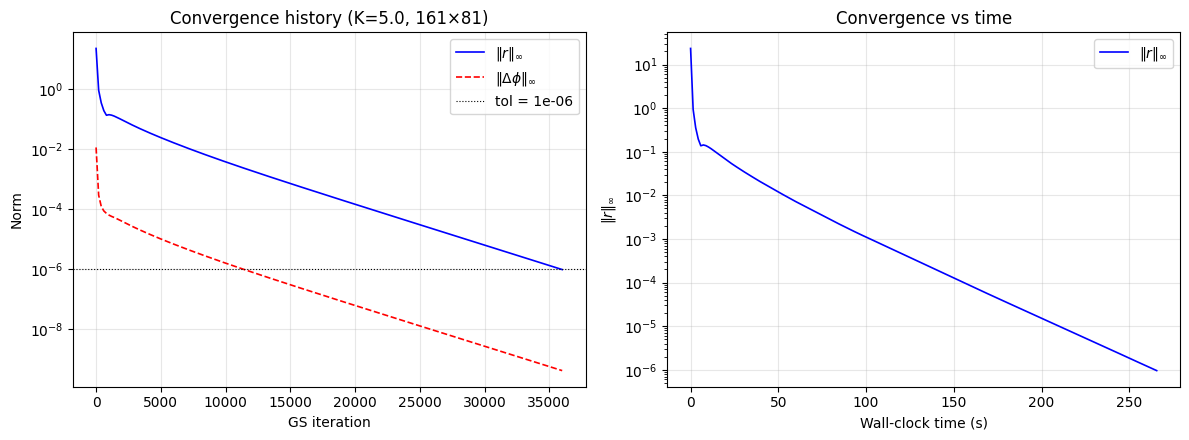

In [173]:
hist = info["hist"]
its  = np.array([h["it"]  for h in hist])
res  = np.array([h["res"] for h in hist])
upd  = np.array([h["upd"] for h in hist])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].semilogy(its, res, "b-", lw=1.2, label=r"$\|r\|_\infty$")
axes[0].semilogy(its, upd, "r--", lw=1.2, label=r"$\|\Delta\phi\|_\infty$")
axes[0].axhline(TOL, color="k", ls=":", lw=0.8, label=f"tol = {TOL:.0e}")
axes[0].set_xlabel("GS iteration")
axes[0].set_ylabel("Norm")
axes[0].set_title(f"Convergence history (K={K}, {Nx}×{Ny})")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

times = np.array([h["time"] for h in hist])
axes[1].semilogy(times, res, "b-", lw=1.2, label=r"$\|r\|_\infty$")
axes[1].set_xlabel("Wall-clock time (s)")
axes[1].set_ylabel(r"$\|r\|_\infty$")
axes[1].set_title("Convergence vs time")
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig("q3_p1_convergence_K5.png", dpi=150, bbox_inches="tight")
plt.show()

3. Surface $\phi_x$ along $y = 0$

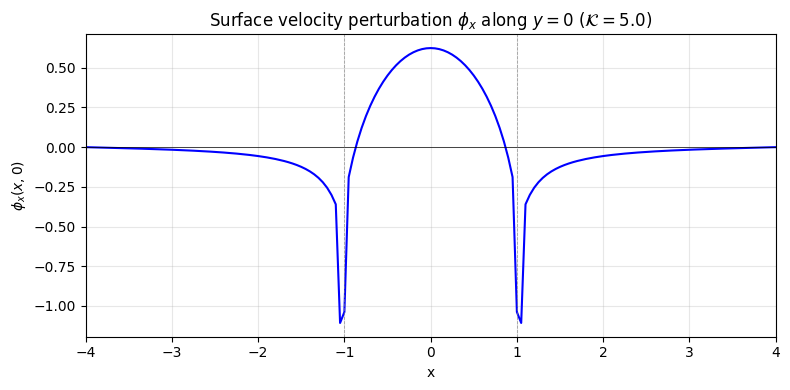

In [174]:
phi_x_surf = surface_phi_x(phi, dx)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, phi_x_surf, "b-", lw=1.5)
ax.axhline(0, color="k", ls="-", lw=0.5)
ax.axvline(-1, color="grey", ls="--", lw=0.6, alpha=0.7)
ax.axvline(1, color="grey", ls="--", lw=0.6, alpha=0.7)
ax.set_xlabel("x"); ax.set_ylabel(r"$\phi_x(x, 0)$")
ax.set_title(rf"Surface velocity perturbation $\phi_x$ along $y=0$ ($\mathcal{{K}}={K}$)")
ax.set_xlim(-q, s); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3_p1_phi_x_surface_K5.png", dpi=150, bbox_inches="tight")
plt.show()

4. Field plots of $\phi_x$, $\phi_y$, $\psi$

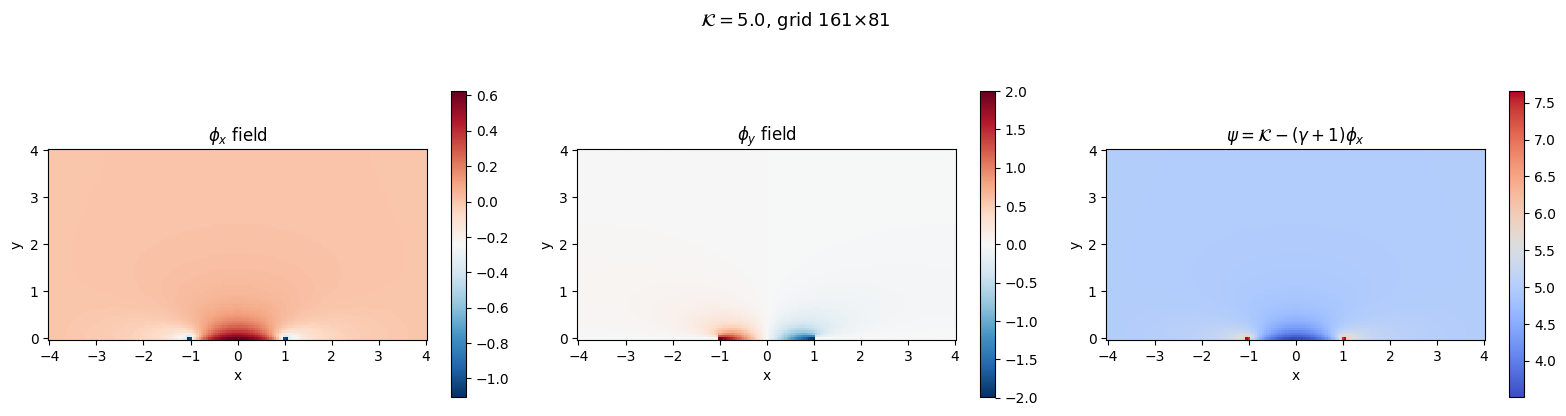


psi_min = 3.5022  (>0 => fully elliptic, as expected)


In [175]:
phi_x_field = compute_phi_x(phi, dx)
phi_y_field = compute_phi_y(phi, dy)
X, Y = np.meshgrid(x, y, indexing="ij")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

c0 = axes[0].pcolormesh(X, Y, phi_x_field, shading="auto", cmap="RdBu_r")
axes[0].set_title(r"$\phi_x$ field"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(c0, ax=axes[0], shrink=0.8)

c1 = axes[1].pcolormesh(X, Y, phi_y_field, shading="auto", cmap="RdBu_r")
axes[1].set_title(r"$\phi_y$ field"); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(c1, ax=axes[1], shrink=0.8)

psi = compute_psi(phi_x_field, K)
c2 = axes[2].pcolormesh(X, Y, psi, shading="auto", cmap="coolwarm")
cs = axes[2].contour(X, Y, psi, levels=[0], colors="k", linewidths=1.5)
axes[2].set_title(r"$\psi = \mathcal{K} - (\gamma+1)\phi_x$")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
plt.colorbar(c2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_aspect("equal")
plt.suptitle(rf"$\mathcal{{K}} = {K}$, grid {Nx}×{Ny}", fontsize=13)
plt.tight_layout()
plt.savefig("q3_p1_fields_K5.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\npsi_min = {psi.min():.4f}  (>0 => fully elliptic, as expected)")